# [Title]

## Preparation

- [Github link](google.com) *[Optional]*

- Number of words: ***

- Runtime: *** hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker (or anything else)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
    - ......

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

In [4]:
# 准备工作：导入本项目需要的库，并统一设置随机种子，保证结果可复现。
# 如果你的 notebook 环境缺少某些库，可先在单独单元运行：
# %pip install pandas numpy matplotlib seaborn scikit-learn geopandas shapely

import sqlite3
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from tempfile import TemporaryDirectory
from urllib.parse import quote
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 设置图形风格，让后续图表在 coursework 中更清晰。
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RANDOM_STATE = 42

# 数据统一从 GitHub raw 链接读取，便于 notebook 在干净环境中复现。
GITHUB_OWNER = "hou1020"
GITHUB_REPO = "CASA0006-coursework"
GITHUB_BRANCH = "main"
GITHUB_RAW_BASE = f"https://raw.githubusercontent.com/{GITHUB_OWNER}/{GITHUB_REPO}/{GITHUB_BRANCH}"

def github_raw_url(path):
    return f"{GITHUB_RAW_BASE}/{quote(path, safe='/')}"

lsoa_crime_url = github_raw_url("MPS LSOA Level Crime (most recent 24 months).csv")
lsoa_historical_crime_url = github_raw_url("MPS LSOA Level Crime (Historical).csv")
oa_lsoa_msoa_lookup_url = github_raw_url("OA21_LAD22_LSOA21_MSOA21_LEP22_EN_LU_V2_789783291718145016.gpkg")
msoa_boundary_url = github_raw_url("Middle_layer_Super_Output_Areas_December_2021_Boundaries_EW_BGC_V3_-1334546435986816930.gpkg")

census_urls = {
    "age": github_raw_url("census2021/census2021-ts007a/census2021-ts007a-msoa.csv"),
    "deprivation": github_raw_url("census2021/census2021-ts011/census2021-ts011-msoa.csv"),
    "accommodation": github_raw_url("census2021/census2021-ts044/census2021-ts044-msoa.csv"),
    "tenure": github_raw_url("census2021/census2021-ts054/census2021-ts054-msoa.csv"),
    "economic": github_raw_url("census2021/census2021-ts066/census2021-ts066-msoa.csv"),
    "qualification": github_raw_url("census2021/census2021-ts067/census2021-ts067-msoa.csv"),
}


## Research questions

[[ go back to the top ]](#Table-of-contents)

In [5]:
# 研究问题对应的机器学习任务：
# 使用 MSOA-level 2021 census features，预测该 MSOA 是否属于高记录犯罪风险区域。
# y = 1 表示 MPS 最新完整一年 MSOA 犯罪率位于 London MSOAs 的前 25%；y = 0 表示其余 MSOAs。

research_question = (
    "To what extent can 2021 Census socio-demographic and built environment features "
    "distinguish high recorded-crime risk MSOAs from other London MSOAs?"
)
print(research_question)


To what extent can 2021 Census socio-demographic and built environment features distinguish high recorded-crime risk MSOAs from other London MSOAs?


## Data

[[ go back to the top ]](#Table-of-contents)

In [6]:
# 1. 读取 LSOA crime、映射到 MSOA，并融合 census features
# 目标变量不再使用 ward profile 或 ward geography。
# Crime: MPS LSOA latest complete 12 months -> aggregate to MSOA via OA/LSOA/MSOA lookup.
# Features: Census 2021 MSOA tables.
lsoa_crime_raw = pd.read_csv(lsoa_crime_url)
print("LSOA crime data shape:", lsoa_crime_raw.shape)

month_cols = sorted([col for col in lsoa_crime_raw.columns if str(col).isdigit()])
annual_month_cols = month_cols[-12:]
print(f"Number of monthly crime columns in source: {len(month_cols)}")
print("Source date range:", min(month_cols), "to", max(month_cols))
print("Annual-rate window used:", min(annual_month_cols), "to", max(annual_month_cols))

lsoa_crime = (
    lsoa_crime_raw
    .assign(Annual_Crime=lsoa_crime_raw[annual_month_cols].sum(axis=1))
    .groupby(["LSOA Code", "LSOA Name", "Borough"], as_index=False)["Annual_Crime"]
    .sum()
)

with TemporaryDirectory() as tmpdir:
    lookup_gpkg_path = Path(tmpdir) / "oa_lsoa_msoa_lookup.gpkg"
    urlretrieve(oa_lsoa_msoa_lookup_url, lookup_gpkg_path)
    with sqlite3.connect(lookup_gpkg_path) as con:
        lsoa_msoa_lookup = pd.read_sql_query(
            """
            SELECT DISTINCT LSOA21CD, LSOA21NM, MSOA21CD, MSOA21NM, LAD22CD, LAD22NM
            FROM OA21_LAD22_LSOA21_MSOA21_LEP22_EN_LU_V2
            """,
            con,
        )

lsoa_crime_mapped = lsoa_crime.merge(
    lsoa_msoa_lookup,
    left_on="LSOA Code",
    right_on="LSOA21CD",
    how="left",
)

lsoa_mapping_summary = pd.DataFrame({
    "metric": ["unique LSOAs in MPS crime", "LSOAs mapped to MSOA", "unmapped LSOAs"],
    "count": [
        lsoa_crime["LSOA Code"].nunique(),
        lsoa_crime_mapped.loc[lsoa_crime_mapped["MSOA21CD"].notna(), "LSOA Code"].nunique(),
        lsoa_crime_mapped.loc[lsoa_crime_mapped["MSOA21CD"].isna(), "LSOA Code"].nunique(),
    ],
})
display(lsoa_mapping_summary)

if lsoa_crime_mapped["MSOA21CD"].isna().any():
    print("Example unmapped LSOAs:")
    display(lsoa_crime_mapped[lsoa_crime_mapped["MSOA21CD"].isna()].head(10))

msoa_crime = (
    lsoa_crime_mapped
    .dropna(subset=["MSOA21CD"])
    .groupby(["MSOA21CD", "MSOA21NM", "LAD22CD", "LAD22NM"], as_index=False)
    .agg(
        Annual_Crime=("Annual_Crime", "sum"),
        LSOA_Count=("LSOA Code", "nunique"),
    )
)

print("MSOA crime data shape:", msoa_crime.shape)
print("London boroughs represented:", msoa_crime["LAD22CD"].nunique())

def load_census_table(key):
    df = pd.read_csv(census_urls[key])
    return df.rename(columns={"geography code": "MSOA21CD", "geography": "MSOA21NM_census"})

age = load_census_table("age")
deprivation = load_census_table("deprivation")
accommodation = load_census_table("accommodation")
tenure = load_census_table("tenure")
economic = load_census_table("economic")
qualification = load_census_table("qualification")

census_features = age[["MSOA21CD", "MSOA21NM_census", "Age: Total"]].copy()
census_features = census_features.rename(columns={"Age: Total": "Population_2021"})

age_child_cols = [
    "Age: Aged 4 years and under",
    "Age: Aged 5 to 9 years",
    "Age: Aged 10 to 14 years",
]
age_young_adult_cols = [
    "Age: Aged 15 to 19 years",
    "Age: Aged 20 to 24 years",
    "Age: Aged 25 to 29 years",
]
age_older_cols = [
    "Age: Aged 65 to 69 years",
    "Age: Aged 70 to 74 years",
    "Age: Aged 75 to 79 years",
    "Age: Aged 80 to 84 years",
    "Age: Aged 85 years and over",
]
census_features["Pct_Children_0_14"] = age[age_child_cols].sum(axis=1) / age["Age: Total"] * 100
census_features["Pct_Young_Adults_15_29"] = age[age_young_adult_cols].sum(axis=1) / age["Age: Total"] * 100
census_features["Pct_Older_65_plus"] = age[age_older_cols].sum(axis=1) / age["Age: Total"] * 100

hh_total = deprivation["Household deprivation: Total: All households; measures: Value"]
census_features["Pct_Households_Deprived_2plus"] = (
    deprivation[
        [
            "Household deprivation: Household is deprived in two dimensions; measures: Value",
            "Household deprivation: Household is deprived in three dimensions; measures: Value",
            "Household deprivation: Household is deprived in four dimensions; measures: Value",
        ]
    ].sum(axis=1) / hh_total * 100
)

accom_total = accommodation["Accommodation type: Total: All households"]
census_features["Pct_Flats"] = (
    accommodation[
        [
            "Accommodation type: In a purpose-built block of flats or tenement",
            "Accommodation type: Part of a converted or shared house, including bedsits",
            "Accommodation type: Part of another converted building, for example, former school, church or warehouse",
            "Accommodation type: In a commercial building, for example, in an office building, hotel or over a shop",
        ]
    ].sum(axis=1) / accom_total * 100
)

tenure_total = tenure["Tenure of household: Total: All households"]
census_features["Pct_Social_Rented"] = tenure["Tenure of household: Social rented"] / tenure_total * 100
census_features["Pct_Private_Rented"] = tenure["Tenure of household: Private rented"] / tenure_total * 100
census_features["Pct_Owner_Occupied"] = tenure["Tenure of household: Owned"] / tenure_total * 100

econ_total = economic["Economic activity status: Total: All usual residents aged 16 years and over"]
census_features["Pct_Unemployed"] = economic["Economic activity status: Economically active (excluding full-time students): Unemployed"] / econ_total * 100
census_features["Pct_Inactive_Long_Term_Sick"] = economic["Economic activity status: Economically inactive: Long-term sick or disabled"] / econ_total * 100

qual_total = qualification["Highest level of qualification: Total: All usual residents aged 16 years and over"]
census_features["Pct_No_Qualifications"] = qualification["Highest level of qualification: No qualifications"] / qual_total * 100
census_features["Pct_Level4_Qualifications"] = qualification["Highest level of qualification: Level 4 qualifications and above"] / qual_total * 100

msoa_df = msoa_crime.merge(census_features, on="MSOA21CD", how="inner")
print(f"MSOA crime-census matched rows: {len(msoa_df)} out of {msoa_crime['MSOA21CD'].nunique()} crime MSOAs")
display(msoa_df.head())


LSOA crime data shape: (105646, 30)
Number of monthly crime columns in source: 25
Source date range: 202403 to 202603
Annual-rate window used: 202504 to 202603


,metric,count
0,unique LSOAs in MPS crime,4988
1,LSOAs mapped to MSOA,4988
2,unmapped LSOAs,0


MSOA crime data shape: (1001, 6)
London boroughs represented: 32
MSOA crime-census matched rows: 1001 out of 1001 crime MSOAs


,MSOA21CD,MSOA21NM,LAD22CD,LAD22NM,Annual_Crime,LSOA_Count,MSOA21NM_census,Population_2021,Pct_Children_0_14,Pct_Young_Adults_15_29,Pct_Older_65_plus,Pct_Households_Deprived_2plus,Pct_Flats,Pct_Social_Rented,Pct_Private_Rented,Pct_Owner_Occupied,Pct_Unemployed,Pct_Inactive_Long_Term_Sick,Pct_No_Qualifications,Pct_Level4_Qualifications
0,E02000002,Barking and Dagenham 001,E09000002,Barking and Dagenham,699,4,Barking and Dagenham 001,8286,26.212889,18.657977,11.211682,32.607749,39.930314,41.777003,14.529617,43.066202,4.661654,5.664160,23.943191,30.910610
1,E02000003,Barking and Dagenham 002,E09000002,Barking and Dagenham,922,6,Barking and Dagenham 002,11539,22.185631,20.071063,11.014819,30.262786,32.374650,13.282443,30.458015,55.623410,4.341927,2.883311,21.301842,34.015143
2,E02000004,Barking and Dagenham 003,E09000002,Barking and Dagenham,394,4,Barking and Dagenham 003,6638,18.650196,19.674601,15.049714,31.522075,13.902122,16.154179,16.284106,66.825466,4.214487,3.631232,23.499530,30.743180
3,E02000005,Barking and Dagenham 004,E09000002,Barking and Dagenham,703,6,Barking and Dagenham 004,11082,26.484389,18.453348,7.967876,29.138322,14.112459,25.137817,21.471885,51.874311,4.044072,4.194316,22.268119,33.783953
4,E02000007,Barking and Dagenham 006,E09000002,Barking and Dagenham,1026,5,Barking and Dagenham 006,10161,24.859758,20.086606,9.615195,30.522946,40.902910,42.219804,16.376496,39.526659,4.391485,5.342081,23.801232,31.703724


*[Note: a table that describes the selected variables for analysis and modelling is required - see the example below.]*

| Variable                            | Type         | Description                                                             |Notes   |
|-------------------------------------|--------------|-------------------------------------------------------------------------|---|
| Burglary crime rate                 | Numeric      | The burglary rate of MSOAs. Used as dependent variables in regression.  |   |
| Temperature                         | Numeric      | The daytime temperature                                                 |   |
| Indicator of Inner or Outer London  | Categorical  | Whether the MSOA is in Inner London.                                    |   |
| ......  | ......  | ......                                    |   |

## Methodology

[[ go back to the top ]](#Table-of-contents)

*[Note: a flow chart that describes the methodology is strongly encouraged - see the example below. This flow chart can be made using Microsoft powerpoint or visio or other software]*

Source: see [link](https://linkinghub.elsevier.com/retrieve/pii/S2210670722004437).

![image.png](attachment:image.png)

In [7]:
# 2. 构建 MSOA 犯罪率与二分类目标变量
# 年犯罪率 = MPS 最新完整 12 个月记录犯罪数 / Census 2021 MSOA population * 1000。
analysis_df = msoa_df.copy()
analysis_df = analysis_df.dropna(subset=["Annual_Crime", "Population_2021"]).copy()
analysis_df["Annual_Crime_Rate"] = (analysis_df["Annual_Crime"] / analysis_df["Population_2021"]) * 1000

# 将 MSOA 犯罪率前 25% 标记为高风险区。
crime_rate_threshold = analysis_df["Annual_Crime_Rate"].quantile(0.75)
analysis_df["High_Risk"] = (analysis_df["Annual_Crime_Rate"] >= crime_rate_threshold).astype(int)

print(f"75th percentile annual crime-rate threshold: {crime_rate_threshold:.2f} crimes per 1,000 residents")
print("Class balance among MSOAs:")
display(
    analysis_df["High_Risk"]
    .value_counts()
    .rename(index={0: "Low risk", 1: "High risk"})
    .to_frame("count")
    .assign(share=lambda x: x["count"] / x["count"].sum())
)

display(
    analysis_df[["MSOA21CD", "MSOA21NM", "LAD22NM", "Annual_Crime", "Population_2021", "Annual_Crime_Rate", "High_Risk"]]
    .sort_values("Annual_Crime_Rate", ascending=False)
    .head(10)
)


75th percentile annual crime-rate threshold: 105.86 crimes per 1,000 residents
Class balance among MSOAs:


,count,share
High_Risk,,
Low risk,750,0.749251
High risk,251,0.250749


,MSOA21CD,MSOA21NM,LAD22NM,Annual_Crime,Population_2021,Annual_Crime_Rate,High_Risk
919,E02000972,Westminster 013,Westminster,22432,7875,2848.507937,1
924,E02000977,Westminster 018,Westminster,17381,6389,2720.457036,1
182,E02000193,Camden 028,Camden,5881,5958,987.076200,1
917,E02000970,Westminster 011,Westminster,6333,6832,926.961358,1
493,E02000524,Hillingdon 031,Hillingdon,5495,7533,729.457056,1
180,E02000191,Camden 026,Camden,3787,5340,709.176030,1
948,E02006801,Lambeth 036,Lambeth,4837,8565,564.740222,1
996,E02007111,Hackney 033,Hackney,3300,5952,554.435484,1
177,E02000186,Camden 021,Camden,3443,6224,553.181234,1
926,E02000979,Westminster 020,Westminster,4333,8086,535.864457,1


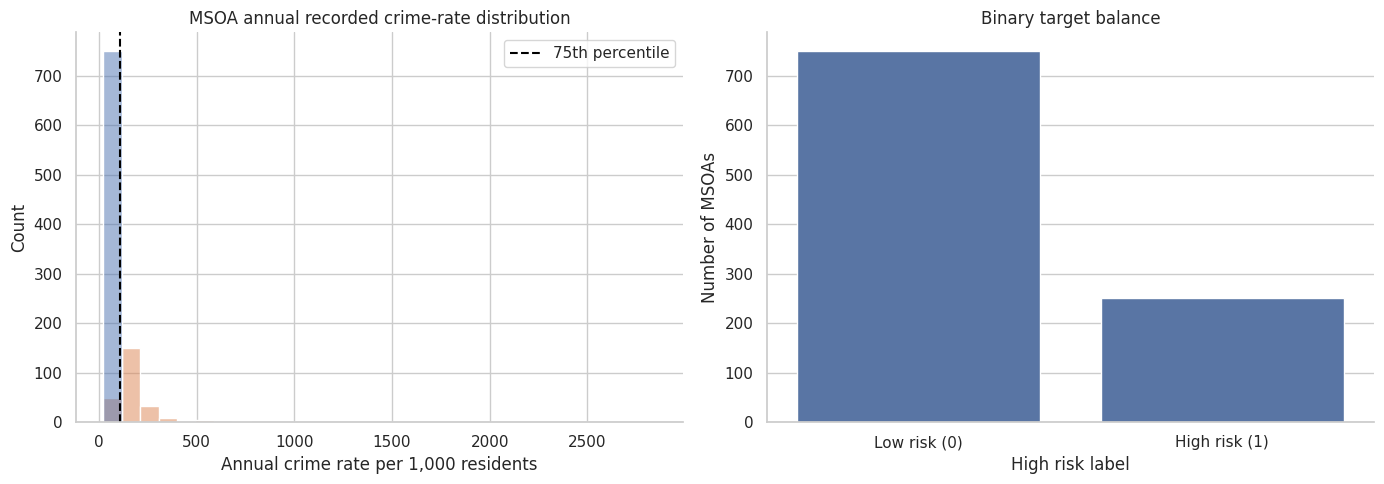

Selected modelling features: 14


,Variable,Type,Missing values,Description / Notes
0,Population_2021,int64,0,Selected Census 2021 MSOA feature
1,LSOA_Count,int64,0,Selected Census 2021 MSOA feature
2,Pct_Children_0_14,float64,0,Selected Census 2021 MSOA feature
3,Pct_Young_Adults_15_29,float64,0,Selected Census 2021 MSOA feature
4,Pct_Older_65_plus,float64,0,Selected Census 2021 MSOA feature
5,Pct_Households_Deprived_2plus,float64,0,Selected Census 2021 MSOA feature
6,Pct_Flats,float64,0,Selected Census 2021 MSOA feature
7,Pct_Social_Rented,float64,0,Selected Census 2021 MSOA feature
8,Pct_Private_Rented,float64,0,Selected Census 2021 MSOA feature
9,Pct_Owner_Occupied,float64,0,Selected Census 2021 MSOA feature


In [8]:
# 3. 探索性分析：目标变量分布与关键变量关系
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=analysis_df, x="Annual_Crime_Rate", hue="High_Risk", bins=30, ax=axes[0])
axes[0].axvline(crime_rate_threshold, color="black", linestyle="--", label="75th percentile")
axes[0].set_title("MSOA annual recorded crime-rate distribution")
axes[0].set_xlabel("Annual crime rate per 1,000 residents")
axes[0].legend()

sns.countplot(data=analysis_df, x="High_Risk", ax=axes[1])
axes[1].set_title("Binary target balance")
axes[1].set_xlabel("High risk label")
axes[1].set_xticklabels(["Low risk (0)", "High risk (1)"])
axes[1].set_ylabel("Number of MSOAs")

plt.tight_layout()
plt.show()

selected_feature_candidates = [
    "Population_2021",
    "LSOA_Count",
    "Pct_Children_0_14",
    "Pct_Young_Adults_15_29",
    "Pct_Older_65_plus",
    "Pct_Households_Deprived_2plus",
    "Pct_Flats",
    "Pct_Social_Rented",
    "Pct_Private_Rented",
    "Pct_Owner_Occupied",
    "Pct_Unemployed",
    "Pct_Inactive_Long_Term_Sick",
    "Pct_No_Qualifications",
    "Pct_Level4_Qualifications",
]
selected_feature_candidates = [col for col in selected_feature_candidates if col in analysis_df.columns]

variable_dictionary = pd.DataFrame({
    "Variable": selected_feature_candidates,
    "Type": [str(analysis_df[col].dtype) for col in selected_feature_candidates],
    "Missing values": [int(analysis_df[col].isna().sum()) for col in selected_feature_candidates],
    "Description / Notes": "Selected Census 2021 MSOA feature",
})
print(f"Selected modelling features: {len(selected_feature_candidates)}")
display(variable_dictionary)


MSOA boundary areas matching analysis data: 1001 out of 1001 analysis MSOAs
Map join labels available for: 1001 out of 1001 displayed MSOAs


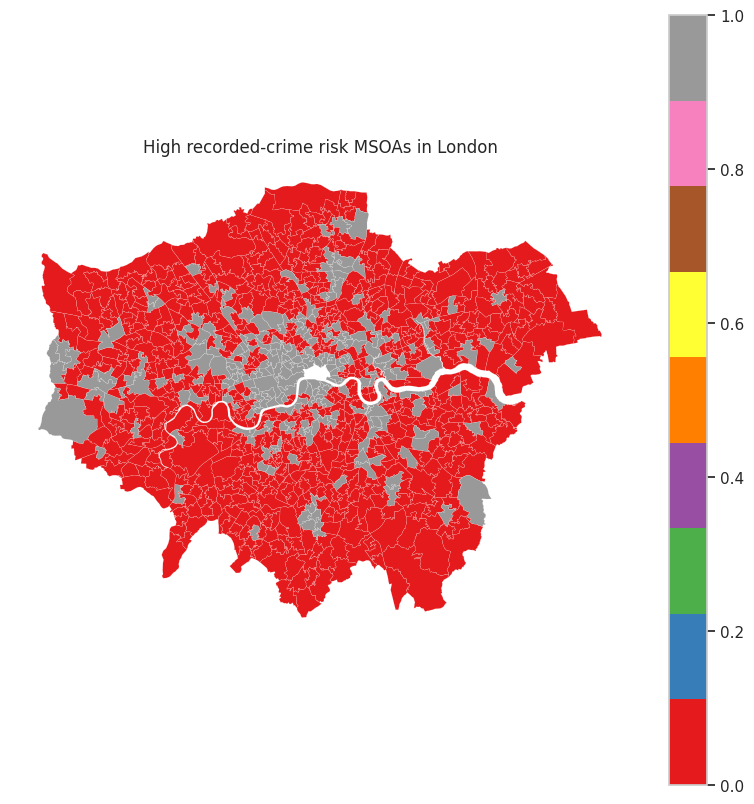

In [9]:
# 4. 空间可视化：高风险 MSOA 等值线地图
# 使用 GitHub 上的 MSOA 2021 boundary GPKG；应与 aggregated MSOA crime-census data 按 MSOA21CD 高匹配。
try:
    import geopandas as gpd

    with TemporaryDirectory() as tmpdir:
        boundary_gpkg_path = Path(tmpdir) / "msoa_boundary.gpkg"
        urlretrieve(msoa_boundary_url, boundary_gpkg_path)
        msoa_gdf = gpd.read_file(boundary_gpkg_path)

    code_col = "MSOA21CD"
    boundary_codes = set(msoa_gdf[code_col])
    analysis_codes = set(analysis_df["MSOA21CD"])
    boundary_matches = len(boundary_codes & analysis_codes)
    print(f"MSOA boundary areas matching analysis data: {boundary_matches} out of {len(analysis_codes)} analysis MSOAs")

    map_gdf = msoa_gdf[msoa_gdf[code_col].isin(analysis_codes)].merge(
        analysis_df[["MSOA21CD", "MSOA21NM", "LAD22NM", "Annual_Crime_Rate", "High_Risk"]],
        on="MSOA21CD",
        how="left",
    )
    mapped_label_count = int(map_gdf["High_Risk"].notna().sum())
    print(f"Map join labels available for: {mapped_label_count} out of {len(map_gdf)} displayed MSOAs")

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    map_gdf.plot(
        column="High_Risk",
        cmap="Set1",
        linewidth=0.1,
        edgecolor="white",
        legend=True,
        missing_kwds={"color": "lightgrey", "label": "No data"},
        ax=ax,
    )
    ax.set_title("High recorded-crime risk MSOAs in London")
    ax.axis("off")
    plt.show()
except Exception as err:
    print("Spatial map skipped because geopandas/MSOA boundary reading is unavailable:", err)


In [10]:
# 5. 建模数据准备
# 删除编码、名称、目标变量和潜在泄漏变量；只使用上一步选定的 Census/MSOA 特征。
X = analysis_df[selected_feature_candidates].copy()
y = analysis_df["High_Risk"].copy()

X = X.dropna(axis=1, how="all")

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

print("Number of selected features:", X.shape[1])
print("Numeric features:", len(numeric_features))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class balance:")
print(y_train.value_counts(normalize=True).sort_index())

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
])


Number of selected features: 14
Numeric features: 14
Train shape: (800, 14)
Test shape: (201, 14)
Train class balance:
High_Risk
0    0.74875
1    0.25125
Name: proportion, dtype: float64


In [11]:
# 6. 基线模型：逻辑回归
# class_weight="balanced" 用于处理 1:3 左右的类别不平衡；模型系数也较容易解释。
log_reg_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

log_reg_model.fit(X_train, y_train)
log_reg_pred = log_reg_model.predict(X_test)

print("Logistic Regression classification report:")
print(classification_report(y_test, log_reg_pred, target_names=["Low risk", "High risk"]))


Logistic Regression classification report:
              precision    recall  f1-score   support

    Low risk       0.90      0.75      0.82       151
   High risk       0.49      0.74      0.59        50

    accuracy                           0.75       201
   macro avg       0.70      0.74      0.70       201
weighted avg       0.80      0.75      0.76       201



In [12]:
# 7. 进阶模型：随机森林分类器
# 随机森林可捕捉非线性关系；class_weight="balanced" 强化少数类（高风险 ward）的学习权重。
rf_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=3,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest classification report:")
print(classification_report(y_test, rf_pred, target_names=["Low risk", "High risk"]))


Random Forest classification report:
              precision    recall  f1-score   support

    Low risk       0.87      0.86      0.86       151
   High risk       0.59      0.60      0.59        50

    accuracy                           0.80       201
   macro avg       0.73      0.73      0.73       201
weighted avg       0.80      0.80      0.80       201



## Results and discussion

[[ go back to the top ]](#Table-of-contents)

Single stratified train-test split performance:


,Model,Precision_high_risk,Recall_high_risk,F1_high_risk
0,Logistic Regression,0.493333,0.74,0.592000
1,Random Forest,0.588235,0.60,0.594059


5-fold StratifiedKFold cross-validation performance:


,Model,CV_precision_high_risk_mean,CV_precision_high_risk_std,CV_recall_high_risk_mean,CV_recall_high_risk_std,CV_f1_high_risk_mean,CV_f1_high_risk_std
0,Logistic Regression,0.511146,0.034081,0.780706,0.084252,0.616182,0.045338
1,Random Forest,0.570701,0.029575,0.557569,0.089732,0.562113,0.060122


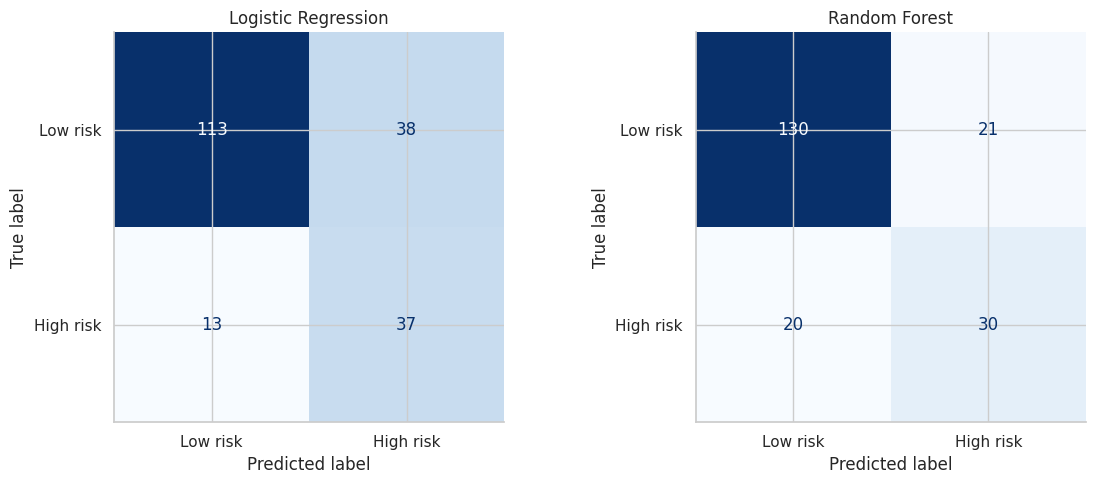

In [13]:
# 8. 模型评估与比较
# 本研究更重视 High risk 的 recall，因为漏判高风险 ward 会影响资源预防性配置。
def collect_metrics(name, y_true, y_pred):
    return {
        "Model": name,
        "Precision_high_risk": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Recall_high_risk": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "F1_high_risk": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

results_df = pd.DataFrame([
    collect_metrics("Logistic Regression", y_test, log_reg_pred),
    collect_metrics("Random Forest", y_test, rf_pred),
]).sort_values("Recall_high_risk", ascending=False)

print("Single stratified train-test split performance:")
display(results_df)

# 加入 StratifiedKFold 交叉验证，减少单次 train-test split 对随机种子的依赖。
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scoring = {
    "precision_high_risk": "precision",
    "recall_high_risk": "recall",
    "f1_high_risk": "f1",
}

cv_rows = []
for name, model in [
    ("Logistic Regression", log_reg_model),
    ("Random Forest", rf_model),
]:
    cv_scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=cv_scoring,
        n_jobs=-1,
        error_score="raise",
    )
    cv_rows.append({
        "Model": name,
        "CV_precision_high_risk_mean": cv_scores["test_precision_high_risk"].mean(),
        "CV_precision_high_risk_std": cv_scores["test_precision_high_risk"].std(),
        "CV_recall_high_risk_mean": cv_scores["test_recall_high_risk"].mean(),
        "CV_recall_high_risk_std": cv_scores["test_recall_high_risk"].std(),
        "CV_f1_high_risk_mean": cv_scores["test_f1_high_risk"].mean(),
        "CV_f1_high_risk_std": cv_scores["test_f1_high_risk"].std(),
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values("CV_recall_high_risk_mean", ascending=False)
print("5-fold StratifiedKFold cross-validation performance:")
display(cv_results_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name, pred in zip(
    axes,
    ["Logistic Regression", "Random Forest"],
    [log_reg_pred, rf_pred],
):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        display_labels=["Low risk", "High risk"],
        cmap="Blues",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()


,feature,coefficient,abs_coefficient
9,Pct_Owner_Occupied,-2.070280,2.070280
13,Pct_Level4_Qualifications,-1.065278,1.065278
12,Pct_No_Qualifications,-0.897630,0.897630
8,Pct_Private_Rented,0.496025,0.496025
4,Pct_Older_65_plus,0.427054,0.427054
10,Pct_Unemployed,-0.259485,0.259485
2,Pct_Children_0_14,-0.255419,0.255419
7,Pct_Social_Rented,-0.145969,0.145969
11,Pct_Inactive_Long_Term_Sick,0.121557,0.121557
0,Population_2021,0.087312,0.087312


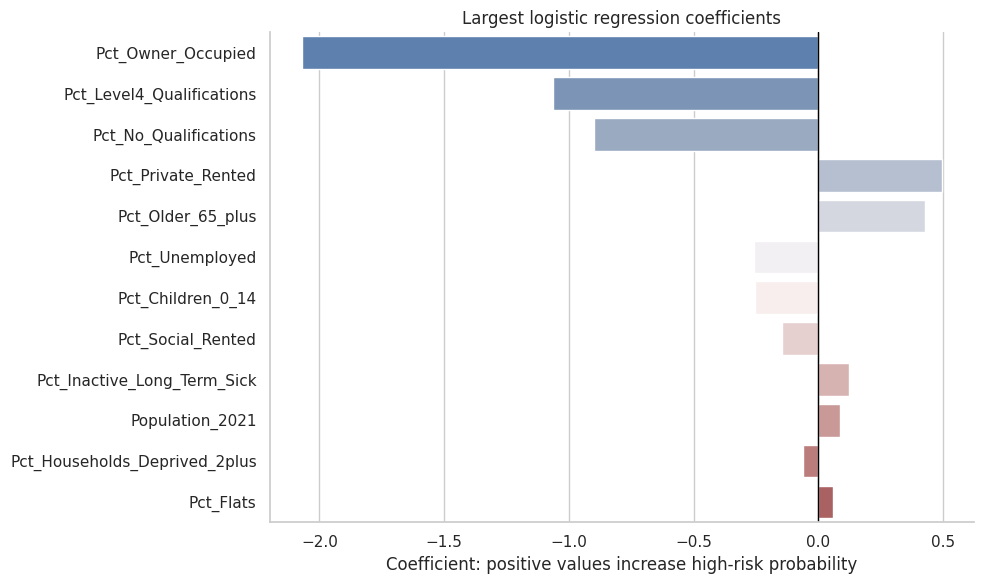

,feature,importance
9,Pct_Owner_Occupied,0.186867
6,Pct_Flats,0.145372
3,Pct_Young_Adults_15_29,0.096101
2,Pct_Children_0_14,0.083930
8,Pct_Private_Rented,0.072594
4,Pct_Older_65_plus,0.063126
7,Pct_Social_Rented,0.061704
10,Pct_Unemployed,0.058195
12,Pct_No_Qualifications,0.047440
11,Pct_Inactive_Long_Term_Sick,0.046782


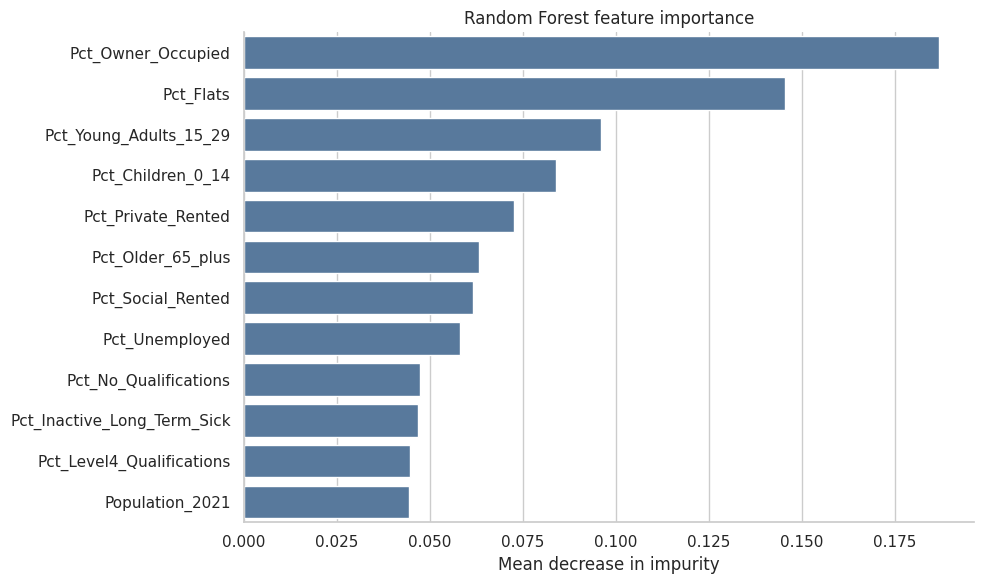

In [14]:
# 9. 模型解释：逻辑回归系数与随机森林特征重要性
# get_feature_names_out() 可以把 ColumnTransformer 后的特征名取回，方便解释模型。
feature_names = log_reg_model.named_steps["preprocess"].get_feature_names_out()
clean_feature_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

coef_df = pd.DataFrame({
    "feature": clean_feature_names,
    "coefficient": log_reg_model.named_steps["model"].coef_[0],
})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_top = coef_df.sort_values("abs_coefficient", ascending=False).head(12)

display(coef_top)

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_top, y="feature", x="coefficient", palette="vlag")
plt.axvline(0, color="black", linewidth=1)
plt.title("Largest logistic regression coefficients")
plt.xlabel("Coefficient: positive values increase high-risk probability")
plt.ylabel("")
plt.tight_layout()
plt.show()

rf_importance_df = pd.DataFrame({
    "feature": clean_feature_names,
    "importance": rf_model.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)
rf_top = rf_importance_df.head(12)

display(rf_top)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_top, y="feature", x="importance", color="#4C78A8")
plt.title("Random Forest feature importance")
plt.xlabel("Mean decrease in impurity")
plt.ylabel("")
plt.tight_layout()
plt.show()


## Conclusion

[[ go back to the top ]](#Table-of-contents)

In [15]:
# 10. 自动生成结果摘要，辅助撰写 Results / Conclusion 部分。
best_model_row = cv_results_df.iloc[0]
print("Model comparison summary")
print("------------------------")
print(f"Best model by cross-validated high-risk recall: {best_model_row['Model']}")
print(f"CV high-risk recall: {best_model_row['CV_recall_high_risk_mean']:.3f} ± {best_model_row['CV_recall_high_risk_std']:.3f}")
print(f"CV high-risk precision: {best_model_row['CV_precision_high_risk_mean']:.3f} ± {best_model_row['CV_precision_high_risk_std']:.3f}")
print(f"CV high-risk F1-score: {best_model_row['CV_f1_high_risk_mean']:.3f} ± {best_model_row['CV_f1_high_risk_std']:.3f}")
print()
print("Interpretation note:")
print(
    "In this resource-allocation framing, false negatives are especially costly because "
    "they represent high-risk wards that the model fails to identify. Therefore recall "
    "for the High risk class should be discussed alongside precision and F1-score. "
    "The modelling evidence applies to MSOAs with matched LSOA crime, Census 2021 features, and MSOA 2021 geography."
)


Model comparison summary
------------------------
Best model by cross-validated high-risk recall: Logistic Regression
CV high-risk recall: 0.781 ± 0.084
CV high-risk precision: 0.511 ± 0.034
CV high-risk F1-score: 0.616 ± 0.045

Interpretation note:
In this resource-allocation framing, false negatives are especially costly because they represent high-risk wards that the model fails to identify. Therefore recall for the High risk class should be discussed alongside precision and F1-score. The modelling evidence applies to MSOAs with matched LSOA crime, Census 2021 features, and MSOA 2021 geography.


## References

[[ go back to the top ]](#Table-of-contents)

In [16]:
# 参考文献记录建议：
# 1. 在正文中引用 Metropolitan Police Service LSOA-level crime data。
# 2. 引用 ONS Census 2021 MSOA tables used for socio-demographic and housing features。
# 3. 引用 ONS OA/LSOA/MSOA lookup and MSOA 2021 boundary data。
# 4. 引用 scikit-learn 文档中 LogisticRegression、RandomForestClassifier、classification_report 等方法。
# 本单元不需要运行；保留为写作提醒。
